# Random Forest

This notebook is a complete end-to-end guide to Random Forest for both interviews and real projects.

What you will learn:
- What Random Forest is and why it works
- Why and when to use it
- When not to use it and what models to try instead
- All important parameters for `RandomForestClassifier` and `RandomForestRegressor`
- How to tune, evaluate, and debug performance
- Easy, practical code examples for classification and regression

---

## Quick Definition

Random Forest is an **ensemble learning** algorithm that builds many decision trees and combines their outputs:
- Classification: majority vote across trees
- Regression: average prediction across trees

It reduces overfitting compared to one deep decision tree by introducing randomness in:
1. Rows (bootstrap samples)
2. Features (random subset at each split)

## Why We Use Random Forest

Random Forest is one of the strongest general-purpose models for tabular data.

Main benefits:
- Strong baseline with little tuning
- Handles nonlinear relationships and feature interactions automatically
- Works for both classification and regression
- Robust to noise and overfitting (compared with a single tree)
- Can estimate feature importance
- Works with mixed feature scales (usually no scaling needed)

In practice, if your data is tabular and you want a reliable first model, Random Forest is often a top choice.

## Why Not Other Models? (Model Selection Intuition)

No model is always best. Choose by data size, speed, interpretability, and metric goals.

### Random Forest vs Logistic Regression / Linear Regression
- Linear models are simpler and more interpretable.
- Use linear models when relationships are close to linear and you need coefficient-level explanation.
- Random Forest wins when interactions and nonlinear patterns matter.

### Random Forest vs Single Decision Tree
- Single tree is easy to explain but often overfits.
- Random Forest usually generalizes better by averaging many trees.

### Random Forest vs Gradient Boosting (XGBoost/LightGBM/CatBoost)
- Boosting often achieves higher final accuracy on many tabular tasks.
- Random Forest is easier to tune and less sensitive to hyperparameters.
- If you need maximum leaderboard performance, test boosting too.

### Random Forest vs SVM
- SVM can be strong for medium-size datasets with good feature engineering.
- Random Forest usually scales better to larger tabular datasets and needs less preprocessing.

### Random Forest vs kNN
- kNN is simple but slow at prediction and sensitive to feature scaling.
- Random Forest predicts faster and handles high-dimensional tabular data better.

### Random Forest vs Neural Networks
- Neural nets shine in images, audio, NLP, and very large datasets.
- For medium tabular data, Random Forest is often easier and very competitive.

## When Random Forest Is Not Ideal
- Very high-cardinality sparse data (some linear models may do better)
- Need strict interpretability and simple decision rules
- Need very fast training on massive datasets (histogram boosting may be faster)
- Strong extrapolation requirement in regression beyond training range

## Theory: How Random Forest Works

### Step-by-step Algorithm
1. Draw a bootstrap sample (sample with replacement) from training data.
2. Train a decision tree on that sample.
3. At each split, consider only a random subset of features (`max_features`).
4. Grow many trees (`n_estimators`).
5. Aggregate predictions from all trees.

### Why This Reduces Overfitting
A single deep tree has low bias and high variance.
Random Forest lowers variance by averaging diverse trees.

If each tree has variance $\sigma^2$ and pairwise correlation $\rho$, variance of the average is approximately:

$$
\mathrm{Var}(\bar{T}) \approx \rho\sigma^2 + \frac{1-\rho}{M}\sigma^2
$$

where $M$ is number of trees.

This equation tells us:
- More trees ($M\uparrow$) reduce variance.
- Lower correlation between trees ($\rho\downarrow$) reduces variance even more.
- Feature randomness helps reduce tree correlation.

### Out-of-Bag (OOB) Estimate
Each tree trains on a bootstrap sample, leaving out some rows.
Those left-out rows are called out-of-bag samples for that tree.
You can predict each row using only trees that did not see it during training.
This gives an internal validation score (`oob_score=True`) without separate validation split.

## Parameters: RandomForestClassifier (Full Practical Guide)

Below are the most important parameters in scikit-learn (`sklearn.ensemble.RandomForestClassifier`).

### Core Size and Randomness
- `n_estimators` (default 100): number of trees.
  - More trees usually improve stability but increase training and prediction time.
- `max_features` (default `"sqrt"`): number of features considered at each split.
  - Smaller value: more diversity, lower correlation, sometimes better generalization.
  - Larger value: stronger individual trees, potentially higher correlation.
- `bootstrap` (default `True`): whether each tree uses bootstrap samples.
- `random_state`: controls reproducibility.

### Tree Depth and Complexity Controls
- `max_depth`: maximum tree depth.
  - Lower depth reduces overfitting.
- `min_samples_split` (default 2): minimum samples required to split an internal node.
- `min_samples_leaf` (default 1): minimum samples in a leaf.
  - Increasing this smooths predictions and reduces variance.
- `min_weight_fraction_leaf`: weighted version of `min_samples_leaf`.
- `max_leaf_nodes`: maximum number of leaf nodes.
- `min_impurity_decrease`: split must reduce impurity by at least this amount.
- `ccp_alpha`: cost-complexity pruning strength.

### Split Quality
- `criterion`:
  - `"gini"` (default): Gini impurity
  - `"entropy"`: information gain
  - `"log_loss"`: logistic loss based split criterion

### Sampling Controls
- `max_samples`: number or fraction of samples drawn for each tree (only if `bootstrap=True`).

### Class Imbalance Controls
- `class_weight`:
  - `None` (default)
  - `"balanced"`
  - `"balanced_subsample"`
  - custom dict `{class_label: weight}`

### Speed / Resource Controls
- `n_jobs`: number of CPU cores to use (`-1` uses all cores).
- `verbose`: print training logs.
- `warm_start`: reuse previous trees and add more when increasing `n_estimators`.

### Validation Control
- `oob_score` (default `False`): calculate out-of-bag score (requires `bootstrap=True`).

---

## Parameters: RandomForestRegressor

Most parameters are the same. Key differences:
- Estimator class: `sklearn.ensemble.RandomForestRegressor`
- `criterion` options are regression criteria, commonly:
  - `"squared_error"` (default)
  - `"absolute_error"`
  - `"friedman_mse"`
  - `"poisson"` (for count-like targets)
- No `class_weight` in regressor

In [8]:
# Imports used in this notebook
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer, fetch_california_housing, make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_recall_curve,
    roc_curve,
)

# Optional plotting
import matplotlib.pyplot as plt

## Easy Code Example 1: Classification

Dataset: Breast Cancer (binary classification)

Goal:
- Train baseline Random Forest
- Evaluate core metrics
- See out-of-bag score and feature importance

In [9]:
# Load data
bc = load_breast_cancer()
X = pd.DataFrame(bc.data, columns=bc.feature_names)
y = pd.Series(bc.target, name="target")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Baseline model
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    oob_score=True,
    n_jobs=-1,
    random_state=42,
)
rf_clf.fit(X_train, y_train)

# Predictions
y_pred = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1]

# Metrics
print("Classification Metrics")
print("-" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1        : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print(f"OOB Score : {rf_clf.oob_score_:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Feature importances
importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 Feature Importances")
print(importances.head(10))

Classification Metrics
----------------------------------------
Accuracy  : 0.9474
Precision : 0.9583
Recall    : 0.9583
F1        : 0.9583
ROC-AUC   : 0.9937
OOB Score : 0.9560

Confusion Matrix
[[39  3]
 [ 3 69]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


Top 10 Feature Importances
worst perimeter         0.137344
worst area              0.137312
worst concave points    0.115502
mean concave points     0.091774
worst radius            0.084111
mean radius             0.062741
mean perimeter          0.049680
mean concavity          0.044142
mean area               0.040508
worst concavity         0.034837
dtype: float64


## Hyperparameter Tuning Strategy (Classifier)

A practical tuning order:
1. Start with enough trees (`n_estimators`: 200 to 800).
2. Control overfitting with `max_depth`, `min_samples_leaf`, `min_samples_split`.
3. Tune tree diversity with `max_features`.
4. For imbalanced data, set `class_weight` and focus on recall/PR-AUC/F1.
5. Use cross-validation and pick metric based on business cost.

Use `RandomizedSearchCV` first (fast), then optional `GridSearchCV` around best region.

In [10]:
# Randomized search for classification
param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [None, 5, 10, 20, 30],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.8],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "bootstrap": [True],
    "class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rs = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rs.fit(X_train, y_train)

print("Best Params:")
print(rs.best_params_)
print(f"Best CV F1: {rs.best_score_:.4f}")

best_rf = rs.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(f"Test F1 with tuned model: {f1_score(y_test, y_pred_best):.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Params:
{'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 20, 'class_weight': None, 'bootstrap': True}
Best CV F1: 0.9701
Test F1 with tuned model: 0.9655


## Easy Code Example 2: Regression

Dataset: California Housing

Goal:
- Train Random Forest Regressor
- Evaluate MAE, RMSE, and $R^2$
- Inspect feature importance

In [11]:
# Load regression data
housing = fetch_california_housing(as_frame=True)
X_reg = housing.data
y_reg = housing.target

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

rf_reg = RandomForestRegressor(
    n_estimators=400,
    max_features=0.8,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)
rf_reg.fit(Xr_train, yr_train)

yr_pred = rf_reg.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)

print("Regression Metrics")
print("-" * 40)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

reg_importance = pd.Series(rf_reg.feature_importances_, index=X_reg.columns).sort_values(ascending=False)
print("\nTop Feature Importances")
print(reg_importance.head(10))

Regression Metrics
----------------------------------------
MAE  : 0.3240
RMSE : 0.5013
R2   : 0.8082

Top Feature Importances
MedInc        0.499474
AveOccup      0.134031
Latitude      0.093357
Longitude     0.092596
AveRooms      0.069428
HouseAge      0.054974
AveBedrms     0.029034
Population    0.027107
dtype: float64


## Interpretability, Pitfalls, and Best Practices

### Feature Importance Caveat
Built-in impurity-based importance can be biased toward high-cardinality features.
For more reliable interpretation, also use permutation importance and SHAP where possible.

### Common Mistakes
- Using accuracy only on imbalanced data
- Too few trees and unstable results
- Ignoring `random_state` (non-reproducible experiments)
- Not using cross-validation
- Overtuning on test data
- Treating feature importance as causal effect

### Practical Best Practices
- Start with `n_estimators` between 200 and 500
- Use `max_features="sqrt"` for classification baseline
- For noisy data, increase `min_samples_leaf`
- Use `class_weight="balanced"` for imbalanced classes
- Track train vs validation gap
- Compare against at least one boosting model

### Time and Space Complexity (High-Level)
- Training cost increases with:
  - number of trees
  - number of samples
  - tree depth
  - number of candidate features
- Prediction cost increases with number of trees and average depth

In short: more trees improve stability but cost more compute.

## Complete Parameter Checklist (Version-Aware)

Even though this notebook explains all major parameters, scikit-learn versions can add new options.
Use the next cell to print the exact full parameter list in your environment.

In [12]:
# Print all available parameters for your installed sklearn version
clf_params = RandomForestClassifier().get_params()
reg_params = RandomForestRegressor().get_params()

print("RandomForestClassifier parameters:")
print("-" * 40)
for k in sorted(clf_params.keys()):
    print(k)

print("\nRandomForestRegressor parameters:")
print("-" * 40)
for k in sorted(reg_params.keys()):
    print(k)

RandomForestClassifier parameters:
----------------------------------------
bootstrap
ccp_alpha
class_weight
criterion
max_depth
max_features
max_leaf_nodes
max_samples
min_impurity_decrease
min_samples_leaf
min_samples_split
min_weight_fraction_leaf
monotonic_cst
n_estimators
n_jobs
oob_score
random_state
verbose
warm_start

RandomForestRegressor parameters:
----------------------------------------
bootstrap
ccp_alpha
criterion
max_depth
max_features
max_leaf_nodes
max_samples
min_impurity_decrease
min_samples_leaf
min_samples_split
min_weight_fraction_leaf
monotonic_cst
n_estimators
n_jobs
oob_score
random_state
verbose
warm_start


## Interview and Job-Ready Answers (Short Form)

1. Why does Random Forest reduce overfitting?
- Because averaging many decorrelated trees reduces variance.

2. Why random feature subsets at each split?
- To reduce correlation among trees, improving ensemble gain.

3. Why use OOB score?
- Gives near-validation estimate without an extra holdout set.

4. Why can feature importance be misleading?
- Impurity importance can favor high-cardinality features.

5. How to handle class imbalance?
- Use `class_weight`, threshold tuning, and proper metrics (F1, PR-AUC, recall).

6. How to improve an underfitting Random Forest?
- Increase `max_depth`, reduce `min_samples_leaf`, increase `max_features`.

7. How to improve an overfitting Random Forest?
- Limit depth, increase `min_samples_leaf`, reduce `max_features`, tune with CV.

8. Why might boosting beat Random Forest?
- Boosting sequentially corrects residual errors and often gives higher accuracy.

9. Is scaling required?
- Usually no, because tree splits are based on thresholds.

10. Can Random Forest extrapolate in regression?
- Not well outside observed feature-target patterns.

---

## Final Cheat Sheet

Use Random Forest when:
- Tabular data
- Nonlinear patterns likely
- Need strong baseline quickly

Be careful when:
- Interpretability is strict requirement
- Dataset is huge and latency budget is tight
- You need best possible leaderboard score (test boosting too)

If you remember one line:

**Random Forest = many randomized trees + averaging -> lower variance, strong practical performance.**

## Visualizations: Feature Importance, ROC Curve, and Precision-Recall Curve

This section gives quick visual diagnostics for the classification model:
- Top feature importances
- ROC curve
- Precision-Recall curve

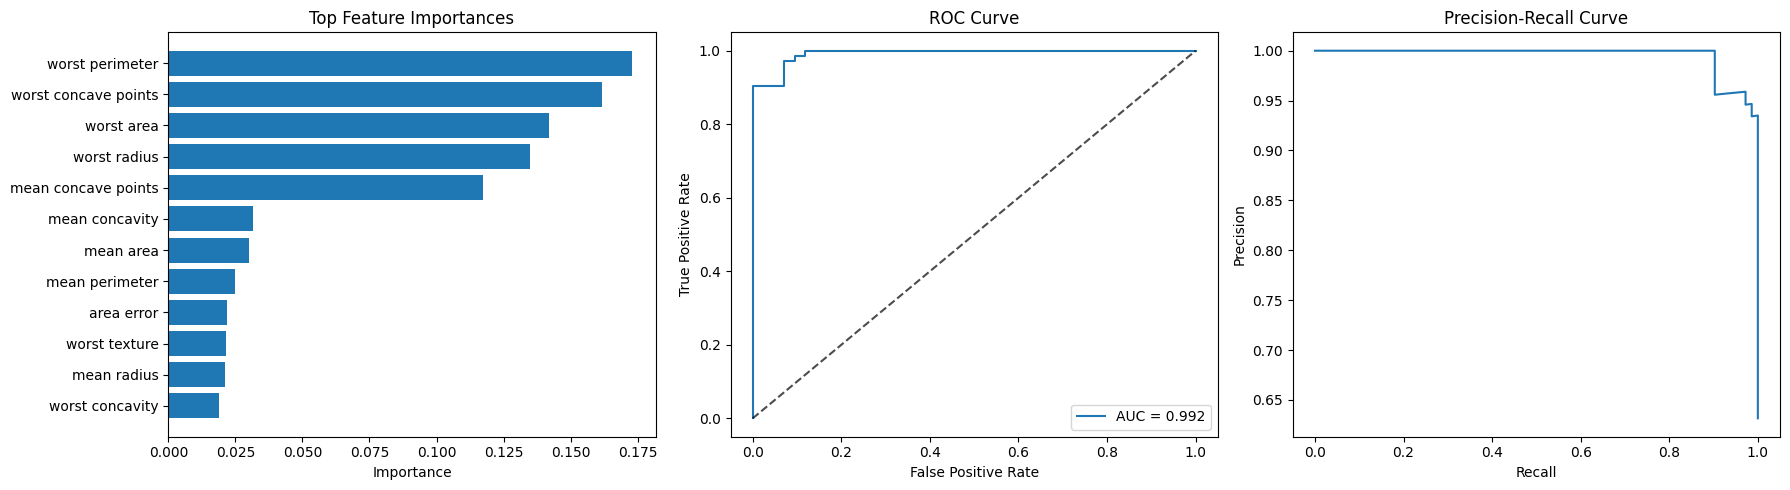

In [13]:
# Visual diagnostics for classification model
plot_model = best_rf if 'best_rf' in globals() else rf_clf
plot_proba = plot_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Feature importance bar chart
feat_imp = pd.Series(plot_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
axes[0].barh(feat_imp.index[::-1], feat_imp.values[::-1])
axes[0].set_title("Top Feature Importances")
axes[0].set_xlabel("Importance")

# 2) ROC curve
fpr, tpr, _ = roc_curve(y_test, plot_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, plot_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.7)
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

# 3) Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, plot_proba)
axes[2].plot(recall, precision)
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")

plt.tight_layout()
plt.show()

## Real-World Style Imbalanced Dataset + Threshold Tuning

This simulates scenarios like fraud detection and disease screening where positives are rare.

What this section demonstrates:
- Why default threshold 0.5 may be suboptimal
- How to search threshold for better F1
- How to enforce minimum precision while maximizing recall

Default threshold (0.5) metrics
----------------------------------------
Precision: 1.0000
Recall   : 0.1963
F1       : 0.3282
ROC-AUC  : 0.9459

Best threshold by F1
----------------------------------------
threshold    0.250000
precision    0.817460
recall       0.631902
f1           0.712803
Name: 20, dtype: float64

Policy threshold (precision >= 0.80, max recall)
----------------------------------------
threshold    0.250000
precision    0.817460
recall       0.631902
f1           0.712803
Name: 20, dtype: float64


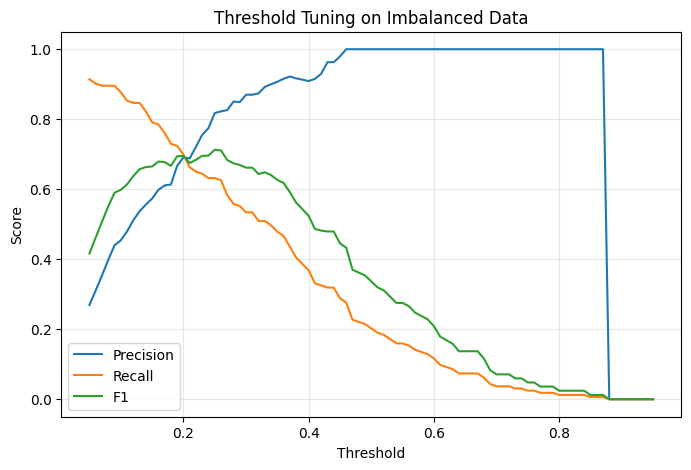

In [14]:
# Create imbalanced binary dataset
X_imb, y_imb = make_classification(
    n_samples=12000,
    n_features=25,
    n_informative=8,
    n_redundant=5,
    n_clusters_per_class=2,
    weights=[0.95, 0.05],
    class_sep=1.2,
    random_state=42,
)

X_imb = pd.DataFrame(X_imb)
y_imb = pd.Series(y_imb)

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_imb, y_imb, test_size=0.25, random_state=42, stratify=y_imb
)

imb_rf = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
imb_rf.fit(Xi_train, yi_train)

# Default threshold = 0.5
default_pred = imb_rf.predict(Xi_test)
default_proba = imb_rf.predict_proba(Xi_test)[:, 1]

print("Default threshold (0.5) metrics")
print("-" * 40)
print(f"Precision: {precision_score(yi_test, default_pred):.4f}")
print(f"Recall   : {recall_score(yi_test, default_pred):.4f}")
print(f"F1       : {f1_score(yi_test, default_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(yi_test, default_proba):.4f}")

# Threshold tuning by F1
thresholds = np.linspace(0.05, 0.95, 91)
records = []
for t in thresholds:
    pred_t = (default_proba >= t).astype(int)
    p = precision_score(yi_test, pred_t, zero_division=0)
    r = recall_score(yi_test, pred_t, zero_division=0)
    f = f1_score(yi_test, pred_t, zero_division=0)
    records.append((t, p, r, f))

th_df = pd.DataFrame(records, columns=["threshold", "precision", "recall", "f1"])
best_row = th_df.loc[th_df["f1"].idxmax()]

print("\nBest threshold by F1")
print("-" * 40)
print(best_row)

# Example policy: choose threshold with precision >= 0.80 and max recall
policy_df = th_df[th_df["precision"] >= 0.80]
if len(policy_df) > 0:
    policy_row = policy_df.loc[policy_df["recall"].idxmax()]
    print("\nPolicy threshold (precision >= 0.80, max recall)")
    print("-" * 40)
    print(policy_row)
else:
    print("\nNo threshold achieved precision >= 0.80 on this split.")

# Plot threshold trade-offs
plt.figure(figsize=(8, 5))
plt.plot(th_df["threshold"], th_df["precision"], label="Precision")
plt.plot(th_df["threshold"], th_df["recall"], label="Recall")
plt.plot(th_df["threshold"], th_df["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning on Imbalanced Data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()